# Rabbits and foxes - with diffusion

First, the original rabbits and foxes problem:

There are initially 400 rabbits and 200 foxes on a farm (but it could be two cell types in a 96 well plate or something, if you prefer bio-engineering analogies). Plot the concentration of foxes and rabbits as a function of time for a period of up to 600 days. The predator-prey relationships are given by the following set of coupled ordinary differential equations:

\begin{align}
\frac{dR}{dt} &= k_1 R - k_2 R F \tag{1}\\
\frac{dF}{dt} &= k_3 R F - k_4 F \tag{2}\\
\end{align}

* Constant for growth of rabbits $k_1 = 0.015$ day<sup>-1</sup>
* Constant for death of rabbits being eaten by foxes $k_2 = 0.00004$ day<sup>-1</sup> foxes<sup>-1</sup>
* Constant for growth of foxes after eating rabbits $k_3 = 0.0004$ day<sup>-1</sup> rabbits<sup>-1</sup>
* Constant for death of foxes $k_4 = 0.04$ day<sup>-1</sup>

*This problem is based on one from Chapter 1 of H. Scott Fogler's textbook "Essentials of Chemical Reaction Engineering".*


In [1]:
%matplotlib inline
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

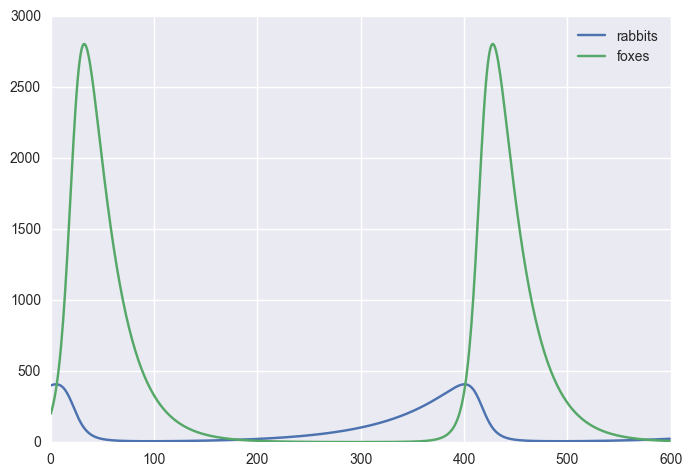

In [2]:
from scipy.integrate import odeint

k1 = 0.015
k2 = 0.00004
k3 = 0.0004
k4 = 0.04
end_time = 600.

def rates(variables, time):
    """
    Return the right hand side of the ODE
    """
    rabbits, foxes = variables
    rate_rabbits = (k1 * rabbits - k2 * rabbits * foxes)
    rate_foxes = (k3 * rabbits * foxes - k4 * foxes)
    return (rate_rabbits, rate_foxes)

times = np.arange(0, end_time)
initial_conditions = (400., 200.)
result = odeint(rates, initial_conditions, times)
rabbits = result[:,0]
foxes = result[:,1]
plt.plot(times, rabbits, label='rabbits')
plt.plot(times, foxes, label='foxes')
plt.legend(loc="best") # put the legend at the best location to avoid overlapping things
plt.show()

# Reaction and diffusion
Now set it up for diffusion on a grid of farms.

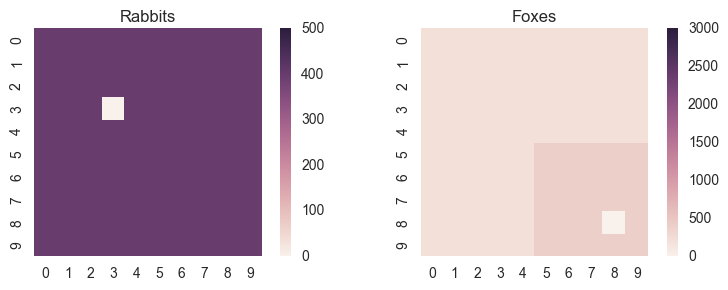

In [3]:
x_max = y_max = 9.0
N = M = 10
dx = x_max / (N-1)
dy = y_max / (M-1)
xgrid = np.linspace(0,x_max,N)
ygrid = np.linspace(0,y_max,M)
assert dx == xgrid[1]

diffusivity_rabbits = 1.0e-3
diffusivity_foxes = 1.0e-3

concentrations = np.ones((2,N,M))
concentrations[0] *= 400
concentrations[1] *= 200
concentrations[1,N//2:,M//2:] *= 2.0 # double foxes in top corner 
concentrations[0,3,3] = 0 # a dead spot of rabbits
concentrations[1,8,8] = 0 # a dead spot of foxes

rabbits = concentrations[0]
foxes = concentrations[1]

plt.subplot(2,2,1)
sns.heatmap(rabbits, square=True, vmin=0, vmax=500)
plt.title('Rabbits')
plt.subplot(2,2,2)
sns.heatmap(foxes, square=True ,vmin=0, vmax=3000)
plt.title('Foxes')
plt.tight_layout()
plt.show()

In [ ]:
# Some practice while I figure things out 
concentrations_vector  = concentrations.reshape(-1)
concentrations = concentrations_vector.reshape((2,N,M))
rabbits = concentrations[0]
foxes = concentrations[1]
np.diff(concentrations, n=2, axis=1)
np.diff(concentrations, n=2, axis=2)


And now the differential equation version

In [ ]:
## Your code here!
# It should end up generating `results` being a 4 dimensional array with the axes
# (time, species, x, y)  where `species` is 0 for rabbits and 1 for foxes.

And now some postprocessing and graphics

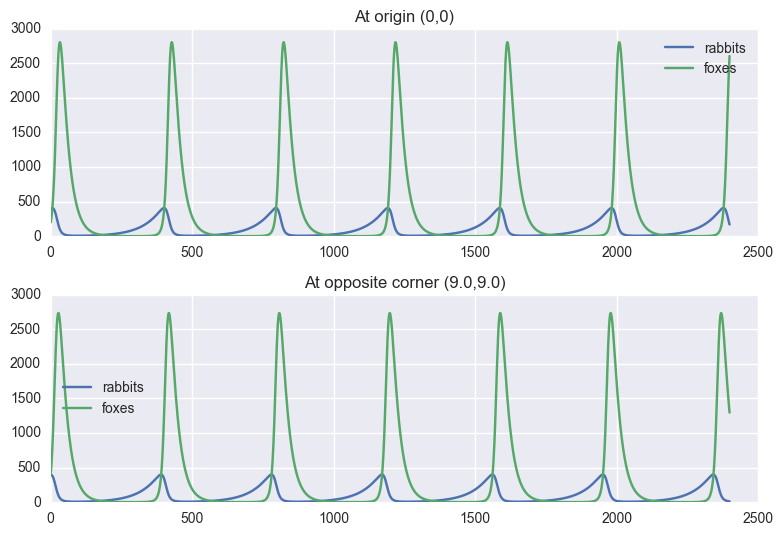

In [6]:
rabbits_origin = results[:,0,0,0]
foxes_origin = results[:,1,0,0]
plt.subplot(2,1,1)
plt.plot(times, rabbits_origin, label='rabbits')
plt.plot(times, foxes_origin, label='foxes')
plt.title("At origin (0,0)")
plt.legend(loc="best")

plt.subplot(2,1,2)
plt.plot(times, results[:,0,-1,-1], label='rabbits')
plt.plot(times, results[:,1,-1,-1], label='foxes')
plt.legend(loc="best") 
plt.title("At opposite corner ({},{})".format(x_max,y_max))
plt.tight_layout()
plt.show()

At end time t=2400.0 days


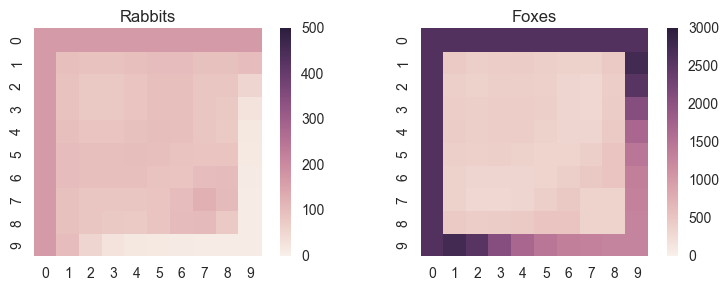

In [7]:
print('At end time t={} days'.format(end_time))
rabbits = results[-1,0]
foxes = results[-1,1]
fig = plt.figure()
plt.subplot(2,2,1)
sns.heatmap(rabbits, square=True,vmin=0,vmax=500)
plt.title('Rabbits')
plt.subplot(2,2,2)
sns.heatmap(foxes, square=True, vmin=0,vmax=3000)
plt.title('Foxes')
plt.tight_layout()
plt.show()

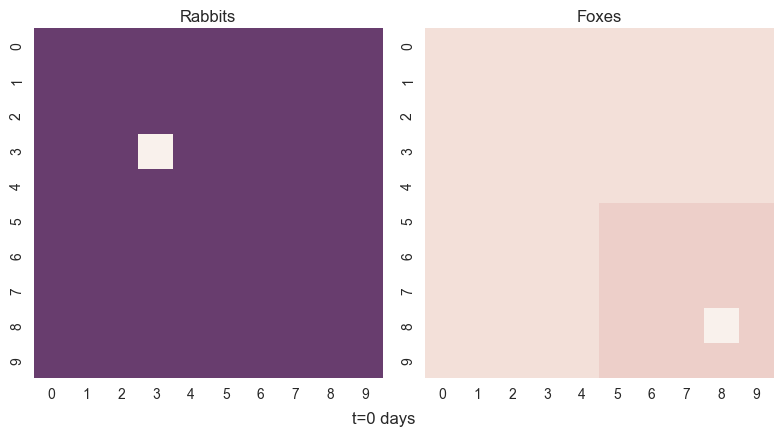

In [16]:
from matplotlib import animation
import matplotlib
matplotlib.rc('animation', html='html5')
fig = plt.figure()
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)
timestamp = fig.text(0.45,0.1,'timestamp')
frames = 120

def animate(i):
    timestep = i * len(times)//(frames)
    rabbits = results[timestep,0]
    foxes = results[timestep,1]
    sns.heatmap(rabbits, square=True, vmin=0,vmax=500, ax=ax1, cbar=None)
    ax1.set_title('Rabbits')
    sns.heatmap(foxes, square=True, vmin=0,vmax=3000, ax=ax2, cbar=None)
    ax2.set_title('Foxes')
    timestamp.set_text('t={0:.0f} days'.format(times[timestep]))
    plt.tight_layout()
    
anim = animation.FuncAnimation(fig, animate, frames=frames, repeat_delay=2000, repeat=True)
anim